# 🏠 Airbnb Madrid — Price Predictor
## Exploratory Data Analysis (EDA)

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [83]:
df = pd.read_csv('../data/listings.csv')

print(df.shape)
print(df.dtypes)
df.head()

(25000, 18)
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                            object
dtype: object


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,NaN,4,33,2018-07-15,0.25,2,198,0,NaN
1,30320,Apartamentos Dana Sol,130907,Danuta Weronika,Centro,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,173,2025-08-27,0.93,17,342,1,NaN
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,8,2017-05-30,0.06,1,0,0,NaN
3,40916,Apartasol Apartamentos Dana,130907,Danuta Weronika,Centro,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,53,2025-09-11,0.29,17,341,4,NaN
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,303845,Arturo,Centro,Justicia,40.41884,-3.69655,Private room,65.0,1,249,2025-09-05,2.78,3,299,41,NaN


In [84]:
df = df.drop(['host_id', 'host_name', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'license', 'id', 'name', 'neighbourhood_group', 'latitude', 'longitude'], axis = 1)

In [85]:
df['price'].describe()

count    18953.000000
mean       156.691447
std        492.255350
min          8.000000
25%         70.000000
50%        110.000000
75%        164.000000
max      25654.000000
Name: price, dtype: float64

In [86]:
IQR = 164 + (1.5 * 94)
IQR

305.0

In [87]:
df.shape

(25000, 7)

In [88]:
df = df[df['price'] <= 305]

In [89]:
df.shape

(17770, 7)

In [90]:
df['price'].describe()

count    17770.000000
mean       114.598537
std         62.299835
min          8.000000
25%         67.000000
50%        105.000000
75%        150.000000
max        305.000000
Name: price, dtype: float64

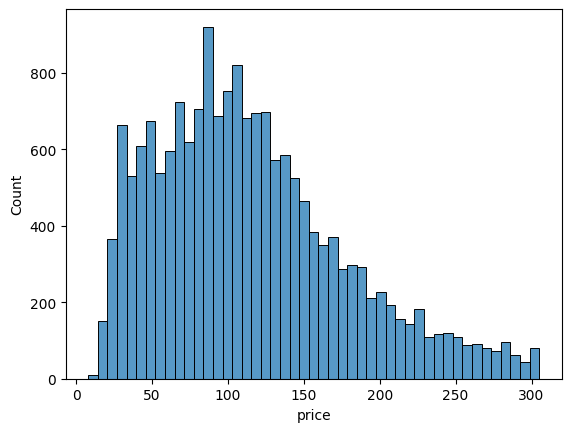

In [91]:
sns.histplot(data = df['price'])
plt.show()

In [92]:
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,number_of_reviews_ltm
1,Sol,Entire home/apt,157.0,5,173,342,1
3,Universidad,Entire home/apt,143.0,5,53,341,4
4,Justicia,Private room,65.0,1,249,299,41
6,Universidad,Entire home/apt,116.0,30,36,305,1
7,Universidad,Entire home/apt,79.0,30,31,317,2


In [93]:
df["neighbourhood"].unique()

array(['Sol', 'Universidad', 'Justicia', 'Embajadores', 'Palacio',
       'Los Angeles', 'Piovera', 'Cortes', 'Canillas', 'Chopera',
       'Valdefuentes', 'Almenara', 'Niño Jesús', 'Lista', 'Rosas',
       'Concepción', 'Hispanoamérica', 'Recoletos', 'Puerta del Angel',
       'San Fermín', 'Comillas', 'Palos de Moguer', 'Lucero',
       'Pueblo Nuevo', 'San Diego', 'Trafalgar', 'Acacias', 'Arcos',
       'Simancas', 'Jerónimos', 'Timón', 'Numancia', 'Pacífico',
       'Marroquina', 'Salvador', 'Goya', 'Gaztambide',
       'Palomeras Sureste', 'Rios Rosas', 'Arapiles', 'San Andrés',
       'Delicias', 'Almagro', 'Nueva España', 'El Viso', 'Valverde',
       'Ventas', 'Casco Histórico de Vallecas', 'Ibiza', 'Prosperidad',
       'Moscardó', 'Fontarrón', 'Cármenes', 'Berruguete', 'Castilla',
       'Argüelles', 'Valdezarza', 'Guindalera', 'Mirasierra',
       'Canillejas', 'Castellana', 'Quintana', 'San Juan Bautista',
       'Aravaca', 'Cuatro Caminos', 'Ciudad Jardín', 'Aluche',
     

In [94]:
pd.set_option('display.max_rows', None)

In [95]:
df["neighbourhood"].value_counts()

neighbourhood
Embajadores                     1878
Universidad                     1566
Palacio                         1354
Sol                              994
Justicia                         861
Cortes                           758
Cuatro Caminos                   343
Trafalgar                        330
Palos de Moguer                  292
Guindalera                       284
Goya                             269
Argüelles                        225
Ibiza                            218
Valdeacederas                    214
Castillejos                      211
Recoletos                        208
Pacífico                         206
Arapiles                         206
San Diego                        199
Berruguete                       193
Numancia                         178
Gaztambide                       178
Puerta del Angel                 175
Lista                            166
Almagro                          166
Rios Rosas                       164
Pueblo Nuevo            

In [96]:
df["neighbourhood"].value_counts().mean()

np.float64(138.828125)

In [97]:
df['room_type'].value_counts()

room_type
Entire home/apt    12636
Private room        4949
Shared room          146
Hotel room            39
Name: count, dtype: int64

In [98]:
df['availability_365'].value_counts()

availability_365
365    307
364    224
0      192
269    170
256    158
257    157
348    129
349    124
335    122
318    106
334    106
317    101
270     99
342     99
332     97
340     97
76      97
319     97
336     97
339     96
346     96
330     94
345     93
326     92
329     91
363     90
343     90
333     90
323     89
344     87
258     86
347     86
350     86
337     84
358     84
226     83
338     83
320     83
341     82
77      82
322     82
89      81
315     81
321     80
316     79
287     78
328     78
1       78
72      77
351     77
327     77
324     76
288     75
297     74
74      74
314     74
313     73
353     73
331     73
352     72
289     72
311     72
305     71
290     69
227     69
75      68
312     68
356     67
303     67
285     67
325     67
232     66
309     66
354     66
299     65
73      65
362     65
268     64
355     64
310     62
267     62
225     62
302     62
306     61
80      60
71      60
301     60
67      59
61      59
308 

In [99]:
df['availability_365'].describe()

count    17770.000000
mean       211.908835
std        115.556720
min          0.000000
25%         96.000000
50%        244.000000
75%        317.000000
max        365.000000
Name: availability_365, dtype: float64

In [100]:
df = df[(df['room_type'] == 'Entire home/apt') | (df['room_type'] == 'Private room')]

In [101]:
df.shape

(17585, 7)

In [102]:
df = df[(df['availability_365'] != 0)]

In [103]:
df.shape

(17393, 7)

In [104]:
top_neighbourhoods = df['neighbourhood'].value_counts()[df['neighbourhood'].value_counts() >= 139].index

In [105]:
top_neighbourhoods

Index(['Embajadores', 'Universidad', 'Palacio', 'Sol', 'Justicia', 'Cortes',
       'Trafalgar', 'Cuatro Caminos', 'Palos de Moguer', 'Guindalera', 'Goya',
       'Argüelles', 'Ibiza', 'Valdeacederas', 'Castillejos', 'Arapiles',
       'Pacífico', 'Recoletos', 'San Diego', 'Berruguete', 'Gaztambide',
       'Numancia', 'Puerta del Angel', 'Lista', 'Almagro', 'Prosperidad',
       'Pueblo Nuevo', 'Ventas', 'Acacias', 'Bellas Vistas', 'Rios Rosas',
       'Almenara', 'San Isidro'],
      dtype='object', name='neighbourhood')

In [106]:
df['neighbourhood'] = np.where(df['neighbourhood'].isin(top_neighbourhoods), df['neighbourhood'], 'Other')

In [107]:
df['neighbourhood'].value_counts()

neighbourhood
Other               4739
Embajadores         1834
Universidad         1496
Palacio             1320
Sol                  973
Justicia             847
Cortes               751
Trafalgar            330
Cuatro Caminos       305
Palos de Moguer      288
Guindalera           282
Goya                 258
Argüelles            221
Ibiza                215
Valdeacederas        213
Castillejos          208
Arapiles             206
Recoletos            204
Pacífico             204
San Diego            196
Berruguete           192
Gaztambide           176
Numancia             174
Puerta del Angel     173
Lista                165
Almagro              164
Prosperidad          162
Pueblo Nuevo         161
Ventas               159
Acacias              158
Bellas Vistas        157
Rios Rosas           156
Almenara             154
San Isidro           152
Name: count, dtype: int64

## ⚙️ Data Preprocessing — Cleaning & Encoding

In [108]:
X = df.drop(['price'], axis = 1)
y = df['price']

In [109]:
X.head()

,neighbourhood,room_type,minimum_nights,number_of_reviews,availability_365,number_of_reviews_ltm
1,Sol,Entire home/apt,5,173,342,1
3,Universidad,Entire home/apt,5,53,341,4
4,Justicia,Private room,1,249,299,41
6,Universidad,Entire home/apt,30,36,305,1
7,Universidad,Entire home/apt,30,31,317,2


In [110]:
X = X.drop(['number_of_reviews_ltm'], axis = 1)

In [111]:
X.head()

,neighbourhood,room_type,minimum_nights,number_of_reviews,availability_365
1,Sol,Entire home/apt,5,173,342
3,Universidad,Entire home/apt,5,53,341
4,Justicia,Private room,1,249,299
6,Universidad,Entire home/apt,30,36,305
7,Universidad,Entire home/apt,30,31,317


In [112]:
X= pd.get_dummies(X, columns = ['neighbourhood', 'room_type'])

In [113]:
X.shape

(17393, 39)

In [114]:
X.dtypes

minimum_nights                    int64
number_of_reviews                 int64
availability_365                  int64
neighbourhood_Acacias              bool
neighbourhood_Almagro              bool
neighbourhood_Almenara             bool
neighbourhood_Arapiles             bool
neighbourhood_Argüelles            bool
neighbourhood_Bellas Vistas        bool
neighbourhood_Berruguete           bool
neighbourhood_Castillejos          bool
neighbourhood_Cortes               bool
neighbourhood_Cuatro Caminos       bool
neighbourhood_Embajadores          bool
neighbourhood_Gaztambide           bool
neighbourhood_Goya                 bool
neighbourhood_Guindalera           bool
neighbourhood_Ibiza                bool
neighbourhood_Justicia             bool
neighbourhood_Lista                bool
neighbourhood_Numancia             bool
neighbourhood_Other                bool
neighbourhood_Pacífico             bool
neighbourhood_Palacio              bool
neighbourhood_Palos de Moguer      bool


In [115]:
X = X.astype(int)

In [116]:
X.dtypes

minimum_nights                    int64
number_of_reviews                 int64
availability_365                  int64
neighbourhood_Acacias             int64
neighbourhood_Almagro             int64
neighbourhood_Almenara            int64
neighbourhood_Arapiles            int64
neighbourhood_Argüelles           int64
neighbourhood_Bellas Vistas       int64
neighbourhood_Berruguete          int64
neighbourhood_Castillejos         int64
neighbourhood_Cortes              int64
neighbourhood_Cuatro Caminos      int64
neighbourhood_Embajadores         int64
neighbourhood_Gaztambide          int64
neighbourhood_Goya                int64
neighbourhood_Guindalera          int64
neighbourhood_Ibiza               int64
neighbourhood_Justicia            int64
neighbourhood_Lista               int64
neighbourhood_Numancia            int64
neighbourhood_Other               int64
neighbourhood_Pacífico            int64
neighbourhood_Palacio             int64
neighbourhood_Palos de Moguer     int64


In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [122]:
X_train.to_csv('../data/X_train.csv', index = False)
X_test.to_csv('../data/X_test.csv', index = False)
y_train.to_csv('../data/y_train.csv', index = False)
y_test.to_csv('../data/y_test.csv', index = False)